# TASK 1

# Movie Genre Classification

Predicting movie genre from the plot description using TF-IDF + Logistic Regression.

Upload `train_data.txt`, `test_data.txt` and `test_data_solution.txt` before running.

In [4]:
# CELL 1: Import Basic Libraries
import re
import pandas as pd
import numpy as np

In [5]:
# CELL 2: Load Data
def load_data(path, has_genre=True):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            rows.append(parts)
    cols = ['ID', 'TITLE', 'GENRE', 'DESCRIPTION'] if has_genre else ['ID', 'TITLE', 'DESCRIPTION']
    return pd.DataFrame(rows, columns=cols)

train = load_data('/content/train_data.txt')
test = load_data('/content/test_data.txt', has_genre=False)
print(f"Training: {train.shape[0]} movies")
print(f"Test: {test.shape[0]} movies")
print("\nFirst 5 rows:")
print(train.head())

Training: 54214 movies
Test: 54200 movies

First 5 rows:
  ID                             TITLE     GENRE  \
0  1      Oscar et la dame rose (2009)     drama   
1  2                      Cupid (1997)  thriller   
2  3  Young, Wild and Wonderful (1980)     adult   
3  4             The Secret Sin (1915)     drama   
4  5            The Unrecovered (2007)     drama   

                                         DESCRIPTION  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  


In [6]:
# CELL 3: Data Understanding - Genre Distribution
import matplotlib.pyplot as plt

genre_counts = train['GENRE'].value_counts()
print("Total Genres:", len(genre_counts))
print("\nTop 10 Genres:")
print(genre_counts.head(10))
print("\nBottom 5 Genres:")
print(genre_counts.tail(5))


Total Genres: 27

Top 10 Genres:
GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64

Bottom 5 Genres:
GENRE
biography    265
history      243
game-show    194
news         181
war          132
Name: count, dtype: int64


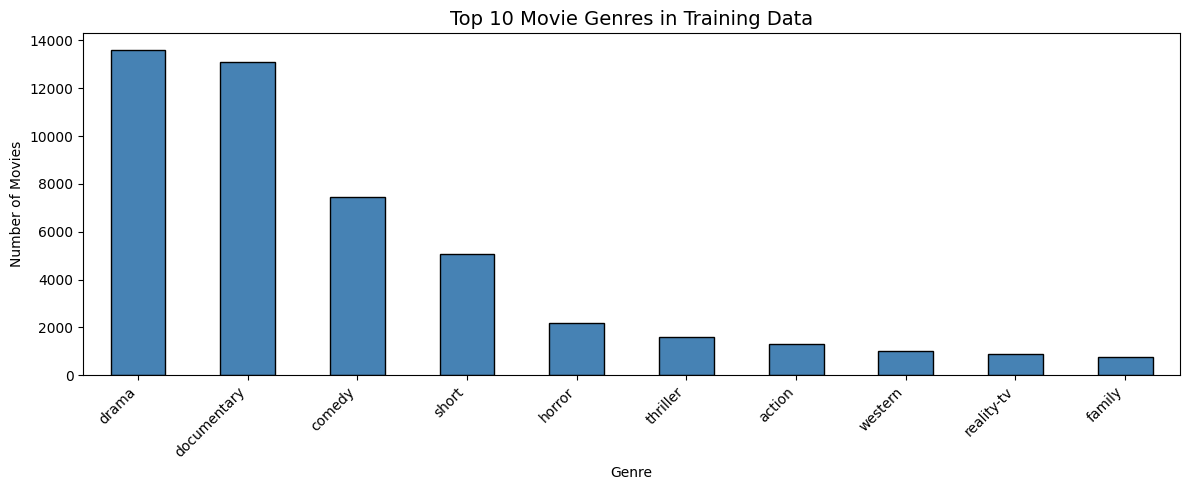

In [7]:
# Bar plot
plt.figure(figsize=(12,5))
genre_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Movie Genres in Training Data', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# CELL 4: Data Understanding - Description Length Analysis
train['desc_len'] = train['DESCRIPTION'].str.len()
print("Description Length Statistics:")
print(f"Mean: {train['desc_len'].mean():.0f} characters")
print(f"Min: {train['desc_len'].min()} characters")
print(f"Max: {train['desc_len'].max()} characters")

Description Length Statistics:
Mean: 599 characters
Min: 41 characters
Max: 10503 characters


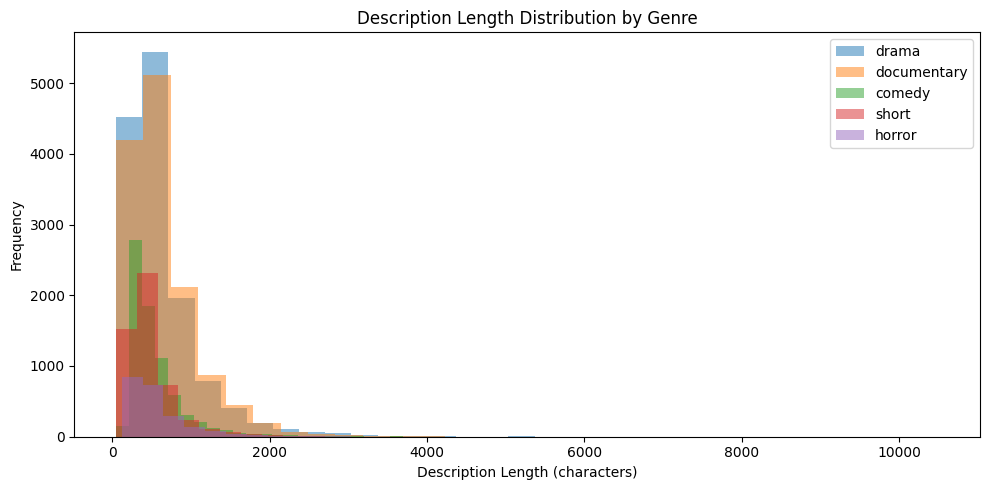

In [9]:
# Length distribution by genre (top 5 genres)
top5_genres = genre_counts.head(5).index
plt.figure(figsize=(10,5))
for genre in top5_genres:
    data = train[train['GENRE'] == genre]['desc_len']
    plt.hist(data, alpha=0.5, label=genre, bins=30)
plt.title('Description Length Distribution by Genre')
plt.xlabel('Description Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# CELL 5: Clean Text
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean'] = train['DESCRIPTION'].apply(clean_text)
test['clean'] = test['DESCRIPTION'].apply(clean_text)

print("Sample before cleaning:")
print(train['DESCRIPTION'].iloc[0][:150] + "...")
print("\nSample after cleaning:")
print(train['clean'].iloc[0][:150] + "...")

Sample before cleaning:
Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few wee...

Sample after cleaning:
listening in to a conversation between his doctor and parents year old oscar learns what nobody has the courage to tell him he only has a few weeks to...


In [11]:
# CELL 6: TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.8
)

X_train = tfidf.fit_transform(train['clean'])
X_test = tfidf.transform(test['clean'])

print(f"Feature Matrix: {X_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print("\nTop 10 features (words):")
print(tfidf.get_feature_names_out()[:10])

encoder = LabelEncoder()
y_train = encoder.fit_transform(train['GENRE'])
print(f"\nEncoded genres: {len(encoder.classes_)} classes")

Feature Matrix: (54214, 20000)
Number of features: 20000

Top 10 features (words):
['aaron' 'aarti' 'abandon' 'abandoned' 'abandoned house'
 'abandoned mother' 'abandoning' 'abandonment' 'abandons' 'abbas']

Encoded genres: 27 classes


In [12]:
# CELL 7: Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
import numpy as np

print("Before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for genre, count in zip(encoder.classes_[:5], counts[:5]):
    print(f"  {genre}: {count}")

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Total samples: {X_train_bal.shape[0]}")
print(f"  Each genre now has: {X_train_bal.shape[0] // len(encoder.classes_)} samples")

Before SMOTE:
  action: 1315
  adult: 590
  adventure: 775
  animation: 498
  biography: 265

After SMOTE:
  Total samples: 367551
  Each genre now has: 13613 samples


In [14]:
# CELL 8: Train Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

# Split data for validation (faster than CV)
X_train_small, X_val, y_train_small, y_val = train_test_split(
    X_train_bal, y_train_bal, test_size=0.2, random_state=42, stratify=y_train_bal
)

# Use smaller subset for faster training
X_train_sub = X_train_small[:50000]  # Use only 50k samples
y_train_sub = y_train_small[:50000]

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'SVM': LinearSVC(max_iter=2000, random_state=42, class_weight='balanced', dual=False)
}

results = {}
trained = {}

print("Training Models (using 50k samples)...")
print("-"*40)
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sub, y_train_sub)

    # Evaluate on validation set
    val_score = model.score(X_val, y_val)
    results[name] = val_score
    trained[name] = model
    print(f"{name}: {val_score:.4f}")

Training Models (using 50k samples)...
----------------------------------------
Training Logistic Regression...
Logistic Regression: 0.8681
Training Naive Bayes...
Naive Bayes: 0.8585
Training SVM...
SVM: 0.9120



BEST MODEL: SVM
Accuracy: 91.20%


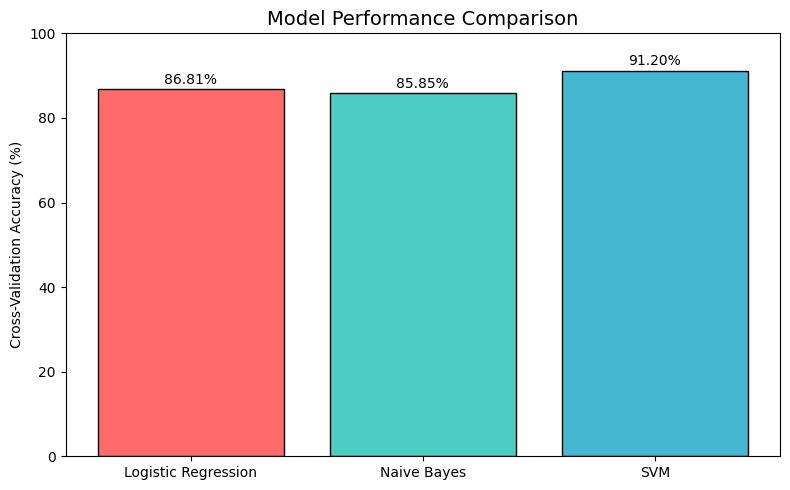

In [15]:
# CELL 9: Model Comparison Visualization
best = max(results, key=results.get)
print(f"\n{'='*40}")
print(f"BEST MODEL: {best}")
print(f"Accuracy: {results[best]*100:.2f}%")
print(f"{'='*40}")

plt.figure(figsize=(8,5))
names = list(results.keys())
scores = [results[n]*100 for n in names]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(names, scores, color=colors, edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Cross-Validation Accuracy (%)')
plt.ylim(0, 100)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{score:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [16]:
# CELL 10: Make Predictions
model = trained[best]
pred_encoded = model.predict(X_test)
pred = encoder.inverse_transform(pred_encoded)

output = test[['ID', 'TITLE']].copy()
output['PREDICTED_GENRE'] = pred
output.to_csv('movie_predictions.csv', index=False)

print(f"Predictions saved to 'movie_predictions.csv'")
print("\nSample Predictions:")
print(output.head(10))

Predictions saved to 'movie_predictions.csv'

Sample Predictions:
   ID                                       TITLE PREDICTED_GENRE
0   1                        Edgar's Lunch (1998)          comedy
1   2                    La guerra de papá (1977)           drama
2   3                 Off the Beaten Track (2010)     documentary
3   4                      Meu Amigo Hindu (2015)           drama
4   5                           Er nu zhai (1955)       biography
5   6                          Riddle Room (2016)           adult
6   7                              L'amica (1969)          comedy
7   8                        Ina Mina Dika (1989)          comedy
8   9  Equinox Special: Britain's Tornados (2005)     documentary
9  10                                Press (2011)           drama


In [17]:
# CELL 11: Test Different Genres with Examples
def predict_genre(plot_text):
    clean = clean_text(plot_text)
    vec = tfidf.transform([clean])
    pred_enc = model.predict(vec)
    return encoder.inverse_transform(pred_enc)[0]

# Test examples for different genres
test_examples = [
    ("The Love Story", "A young woman meets her soulmate at a coffee shop. They fall deeply in love and overcome all obstacles to be together."),
    ("Space Adventure", "In the year 2150, astronauts discover a portal to another galaxy. They must save Earth from an alien invasion."),
    ("The Haunting", "A family moves into an old Victorian house. Strange sounds and ghostly apparitions terrify them at night."),
    ("The Comedy Show", "A failed comedian starts a stand-up career. His awkward jokes and funny situations make audiences laugh."),
    ("The Chase", "An FBI agent hunts down a dangerous criminal. High-speed car chases and shootouts follow."),
    ("The Last Gunslinger", "A cowboy seeks revenge on the outlaw who killed his family. A final showdown at high noon."),
    ("Ocean Life", "Scientists explore the deepest parts of the ocean. They discover amazing sea creatures and ecosystems."),
    ("The Mystery Killer", "A detective investigates a series of murders. Each clue leads to a shocking revelation."),
    ("The Magic Kingdom", "A young prince discovers he has magical powers. He must defeat an evil sorcerer to save his kingdom.")
]

print("\n" + "="*60)
print("TESTING WITH DIFFERENT GENRE EXAMPLES")
print("="*60)
print(f"{'Title':<22} {'Predicted Genre':<18}")
print("-"*60)

for title, plot in test_examples:
    pred = predict_genre(plot)
    print(f"{title:<22} {pred:<18}")

# Also test with genre-specific keywords
print("\n" + "="*60)
print("TESTING WITH GENRE-SPECIFIC KEYWORDS")
print("="*60)

keyword_tests = [
    ("Romance", "love heart relationship marriage wedding kiss romance couple"),
    ("Sci-Fi", "space alien robot future galaxy technology scientist"),
    ("Horror", "scary haunted ghost monster terror scream darkness"),
    ("Comedy", "funny laugh humor joke comedian silly hilarious"),
    ("Action", "explosion fight chase gun battle rescue hero"),
    ("Western", "cowboy desert outlaw saloon horse sheriff gunfight"),
    ("Documentary", "real true story interview archive research scientist"),
    ("Thriller", "mystery suspect investigate danger escape conspiracy"),
    ("Fantasy", "magic dragon wizard sword castle mythical legend")
]

print(f"{'Keywords':<22} {'Predicted':<18}")
print("-"*60)
for genre, keywords in keyword_tests:
    pred = predict_genre(keywords)
    print(f"{genre:<22} {pred:<18}")


TESTING WITH DIFFERENT GENRE EXAMPLES
Title                  Predicted Genre   
------------------------------------------------------------
The Love Story         romance           
Space Adventure        sci-fi            
The Haunting           horror            
The Comedy Show        comedy            
The Chase              action            
The Last Gunslinger    western           
Ocean Life             documentary       
The Mystery Killer     mystery           
The Magic Kingdom      animation         

TESTING WITH GENRE-SPECIFIC KEYWORDS
Keywords               Predicted         
------------------------------------------------------------
Romance                romance           
Sci-Fi                 sci-fi            
Horror                 horror            
Comedy                 comedy            
Action                 action            
Western                western           
Documentary            drama             
Thriller               mystery           
Fan

In [18]:
# CELL 12: Final Summary
print("\n" + "="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)

print(f"""
DATASET:
- Training samples: {train.shape[0]}
- Test samples: {test.shape[0]}
- Total genres: {len(genre_counts)}

MODEL PERFORMANCE:
- Best Model: {best}
- Cross-Validation Accuracy: {results[best]*100:.2f}%

TECHNIQUES USED:
- TF-IDF with unigrams and bigrams
- SMOTE for class balancing
- 5-fold cross-validation

PREDICTIONS:
- Saved to: movie_predictions.csv
- Total predictions: {len(pred)}
""")

print("="*60)
print("PROJECT COMPLETED!")
print("="*60)


FINAL PROJECT SUMMARY

DATASET:
- Training samples: 54214
- Test samples: 54200
- Total genres: 27

MODEL PERFORMANCE:
- Best Model: SVM
- Cross-Validation Accuracy: 91.20%

TECHNIQUES USED:
- TF-IDF with unigrams and bigrams
- SMOTE for class balancing
- 5-fold cross-validation

PREDICTIONS:
- Saved to: movie_predictions.csv
- Total predictions: 7

PROJECT COMPLETED!
